In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path("/rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/processed_md_features")

files = list(BASE.rglob("*_features.csv"))
print(f"Found {len(files)} files")

dfs = []
for file in files:
    df = pd.read_csv(file)
    df["source_file"] = file.name
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print(data.shape)
data.head()

Found 18 files
(15018, 20)


,protein_rg,local_env_rg,local_env_n_atoms,local_env_to_triad_min_distance,backbone_rmsd,triad_d01,triad_d02,triad_d12,triad_area,substrate_rg,substrate_to_triad_min_distance,substrate_to_local_env_contacts_4A,substrate_to_local_env_contacts_5A,variant,condition,state,replicate,frame,time_ps,source_file
0,30.293320,20.444221,2282,2.134859,0.000003,4.881456,5.733455,4.582587,10.778051,7.313546,2.589550,368.0,977.0,f134w_d304m_r330a,ace_coo,bound,3,0,0.0,f134w_d304m_r330a_ace_coo_rep3_features.csv
1,30.736238,20.596075,2282,2.000845,1.080080,4.084535,5.020618,4.780652,9.082206,7.370800,2.800770,242.0,764.0,f134w_d304m_r330a,ace_coo,bound,3,1,200.0,f134w_d304m_r330a_ace_coo_rep3_features.csv
2,30.712378,20.668650,2282,2.081463,1.160687,4.626332,5.501950,4.968239,10.790851,6.884095,2.576236,261.0,797.0,f134w_d304m_r330a,ace_coo,bound,3,2,400.0,f134w_d304m_r330a_ace_coo_rep3_features.csv
3,30.635010,20.662734,2282,1.786560,1.151268,4.752193,5.910307,4.761241,11.014991,7.551736,2.680785,253.0,769.0,f134w_d304m_r330a,ace_coo,bound,3,3,600.0,f134w_d304m_r330a_ace_coo_rep3_features.csv
4,30.689559,20.675752,2282,1.797161,1.186444,4.041436,5.030842,4.815122,9.058371,7.825886,2.805440,233.0,722.0,f134w_d304m_r330a,ace_coo,bound,3,4,800.0,f134w_d304m_r330a_ace_coo_rep3_features.csv


In [2]:
data[["variant", "condition", "state", "replicate"]].drop_duplicates().sort_values(
    ["variant", "condition", "replicate"]
)

,variant,condition,state,replicate
14017,D99R,no_substrate,apo,1
12015,D99R,no_substrate,apo,2
13016,D99R,no_substrate,apo,3
9762,D99R_f134w_d304m_r330a,ace_coo,bound,1
10513,D99R_f134w_d304m_r330a,ace_coo,bound,2
11264,D99R_f134w_d304m_r330a,ace_coo,bound,3
6008,WT,ace_coo,bound,1
5257,WT,ace_coo,bound,2
4506,WT,ace_coo,bound,3
3004,WT,coo_ace,bound,1


In [3]:
meta_cols = ["variant", "condition", "state", "replicate", "frame", "time_ps", "source_file"]
feature_cols = [c for c in data.columns if c not in meta_cols and pd.api.types.is_numeric_dtype(data[c])]

feature_cols

['protein_rg',
 'local_env_rg',
 'local_env_n_atoms',
 'local_env_to_triad_min_distance',
 'backbone_rmsd',
 'triad_d01',
 'triad_d02',
 'triad_d12',
 'triad_area',
 'substrate_rg',
 'substrate_to_triad_min_distance',
 'substrate_to_local_env_contacts_4A',
 'substrate_to_local_env_contacts_5A']

In [4]:
summary = (
    data
    .groupby(["variant", "condition", "replicate"])[feature_cols]
    .agg(["mean", "std", "min", "max"])
)

summary.head()

protein_rg                       \
                                                    mean       std        min   
variant                condition    replicate                                   
D99R                   no_substrate 1          30.831994  0.078704  30.631249   
                                    2          30.802271  0.061031  30.617513   
                                    3          30.839516  0.059747  30.632315   
D99R_f134w_d304m_r330a ace_coo      1          30.859069  0.083540  30.290299   
                                    2          31.032005  0.072778  30.283542   

                                                         local_env_rg  \
                                                     max         mean   
variant                condition    replicate                           
D99R                   no_substrate 1          31.064677    20.342644   
                                    2          30.978426    20.214978   
                                    3          31.022410    20.306206   
D99R_f134w_d304m_r330a ace_coo      1          31.106548    20.423470   
                                    2          31.213958    20.585771   

                                                                               \
                                                    std        min        max   
variant                condition    replicate                                   
D99R                   no_substrate 1          0.074160  20.077317  20.622413   
                                    2          0.074755  19.944890  20.468196   
                                    3          0.082426  20.054142  20.550749   
D99R_f134w_d304m_r330a ace_coo      1          0.086849  20.189358  20.685883   
                                    2          0.073018  20.257694  20.802713   

                                              local_env_n_atoms       ...  \
                                                           mean  std  ...   
variant                condition    replicate                         ...   
D99R                   no_substrate 1                    2203.0  0.0  ...   
                                    2                    2173.0  0.0  ...   
                                    3                    2125.0  0.0  ...   
D99R_f134w_d304m_r330a ace_coo      1                    2271.0  0.0  ...   
                                    2                    2274.0  0.0  ...   

                                              substrate_to_triad_min_distance  \
                                                                          min   
variant                condition    replicate                                   
D99R                   no_substrate 1                                     NaN   
                                    2                                     NaN   
                                    3                                     NaN   
D99R_f134w_d304m_r330a ace_coo      1                                2.327448   
                                    2                                2.171563   

                                                         \
                                                    max   
variant                condition    replicate             
D99R                   no_substrate 1               NaN   
                                    2               NaN   
                                    3               NaN   
D99R_f134w_d304m_r330a ace_coo      1          3.854383   
                                    2          3.400192   

                                              substrate_to_local_env_contacts_4A  \
                                                                            mean   
variant                condition    replicate                                      
D99R                   no_substrate 1                                        NaN   
                                    2                                        NaN   
    

In [5]:
summary_flat = summary.copy()
summary_flat.columns = ["_".join(col) for col in summary_flat.columns]
summary_flat = summary_flat.reset_index()

summary_flat.head()

,variant,condition,replicate,protein_rg_mean,protein_rg_std,protein_rg_min,protein_rg_max,local_env_rg_mean,local_env_rg_std,local_env_rg_min,...,substrate_to_triad_min_distance_min,substrate_to_triad_min_distance_max,substrate_to_local_env_contacts_4A_mean,substrate_to_local_env_contacts_4A_std,substrate_to_local_env_contacts_4A_min,substrate_to_local_env_contacts_4A_max,substrate_to_local_env_contacts_5A_mean,substrate_to_local_env_contacts_5A_std,substrate_to_local_env_contacts_5A_min,substrate_to_local_env_contacts_5A_max
0,D99R,no_substrate,1,30.831994,0.078704,30.631249,31.064677,20.342644,0.074160,20.077317,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,D99R,no_substrate,2,30.802271,0.061031,30.617513,30.978426,20.214978,0.074755,19.944890,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,D99R,no_substrate,3,30.839516,0.059747,30.632315,31.022410,20.306206,0.082426,20.054142,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,D99R_f134w_d304m_r330a,ace_coo,1,30.859069,0.083540,30.290299,31.106548,20.423470,0.086849,20.189358,...,2.327448,3.854383,194.59787,52.694827,101.0,400.0,577.033289,150.271870,346.0,1101.0
4,D99R_f134w_d304m_r330a,ace_coo,2,31.032005,0.072778,30.283542,31.213958,20.585771,0.073018,20.257694,...,2.171563,3.400192,315.79494,45.051325,200.0,476.0,948.584554,109.881478,684.0,1252.0


In [6]:
def plot_feature_timeseries(df, feature):
    for (variant, condition), sub in df.groupby(["variant", "condition"]):
        plt.figure(figsize=(9, 4))

        for rep, rep_df in sub.groupby("replicate"):
            rep_df = rep_df.sort_values("time_ps")
            plt.plot(rep_df["time_ps"] / 1000, rep_df[feature], label=f"rep {rep}", alpha=0.8)

        plt.title(f"{feature}: {variant} | {condition}")
        plt.xlabel("Time [ns]")
        plt.ylabel(feature)
        plt.legend()
        plt.tight_layout()
        plt.show()

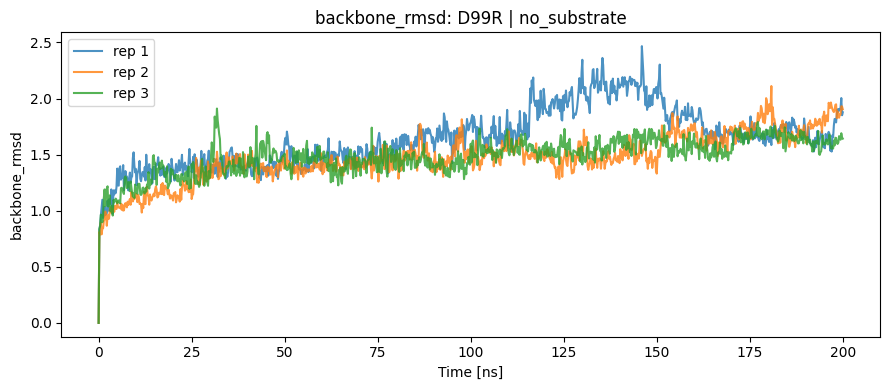

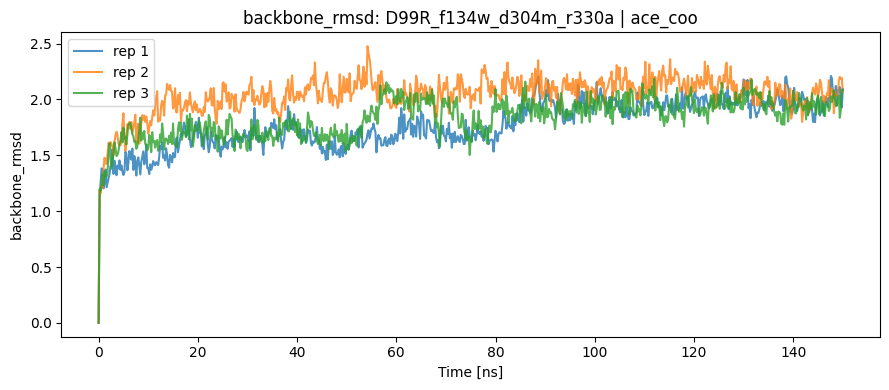

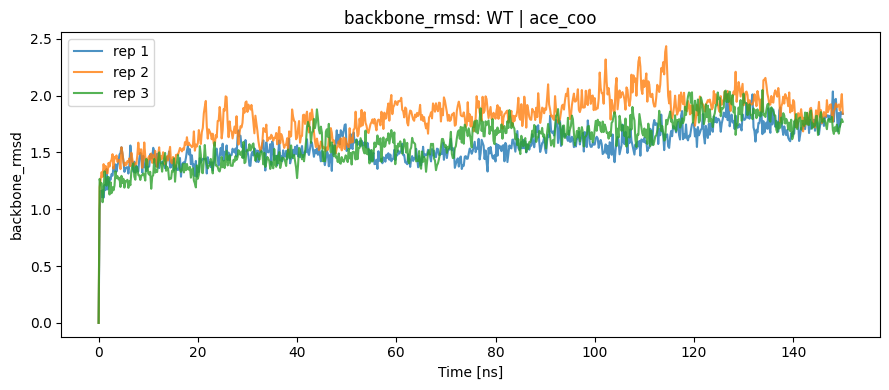

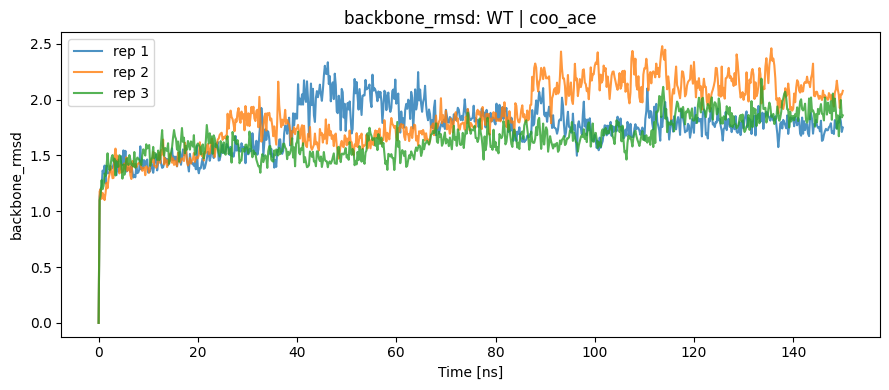

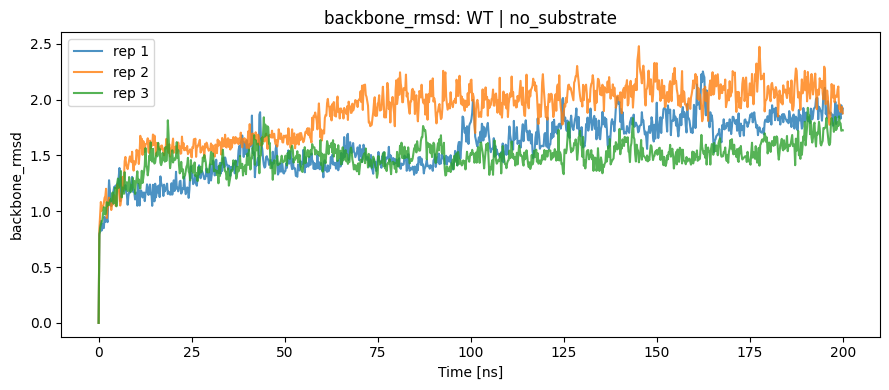

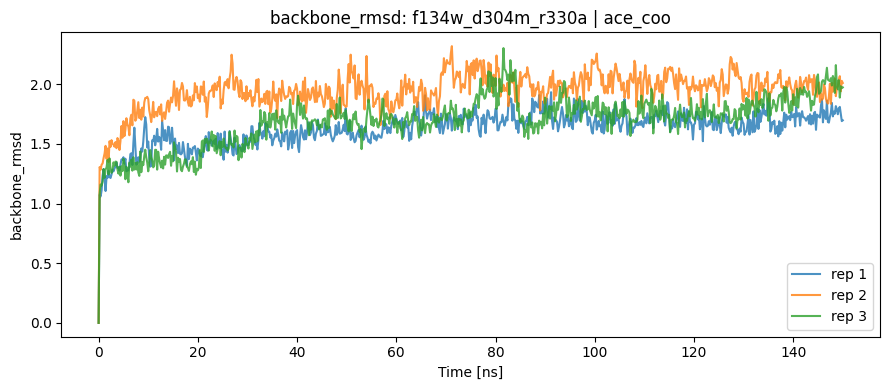

In [7]:
plot_feature_timeseries(data, "backbone_rmsd")

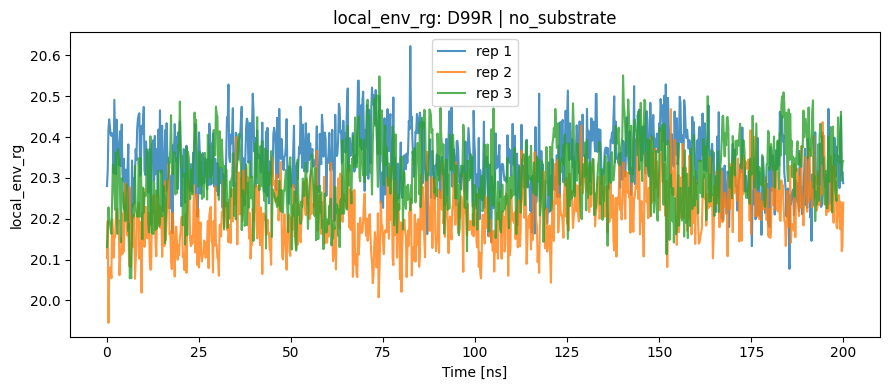

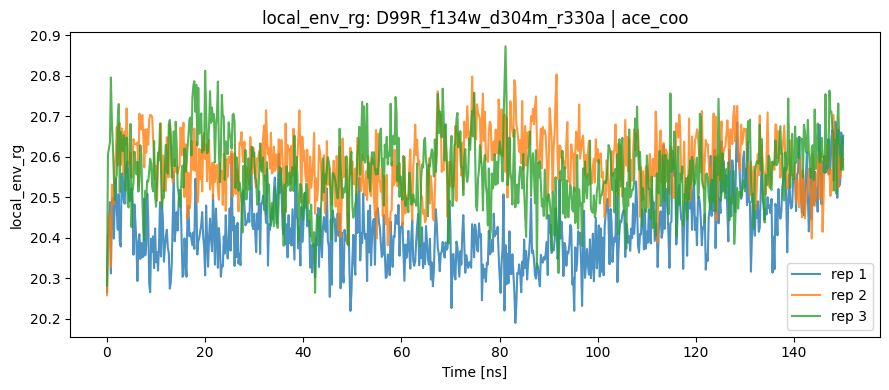

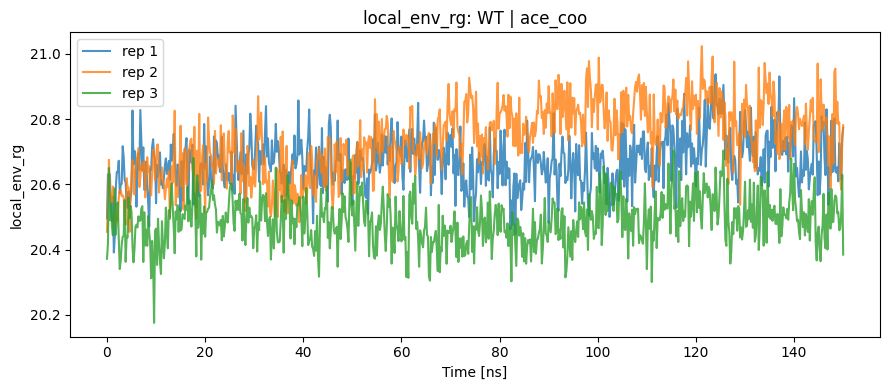

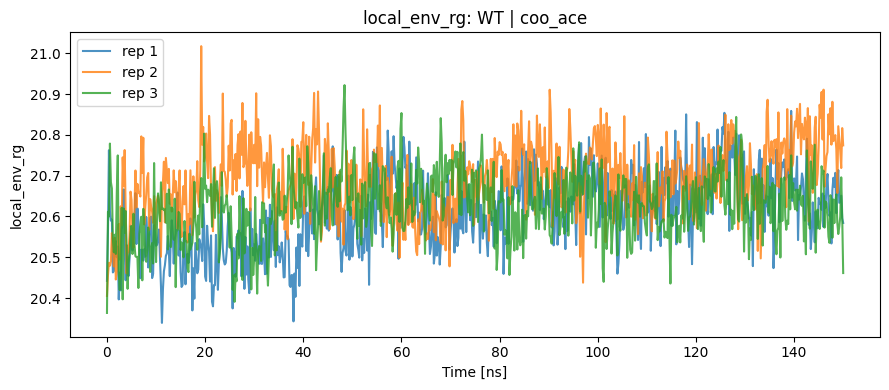

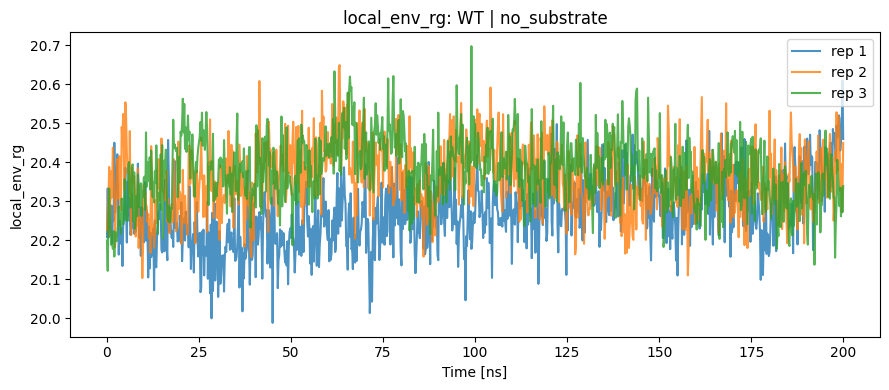

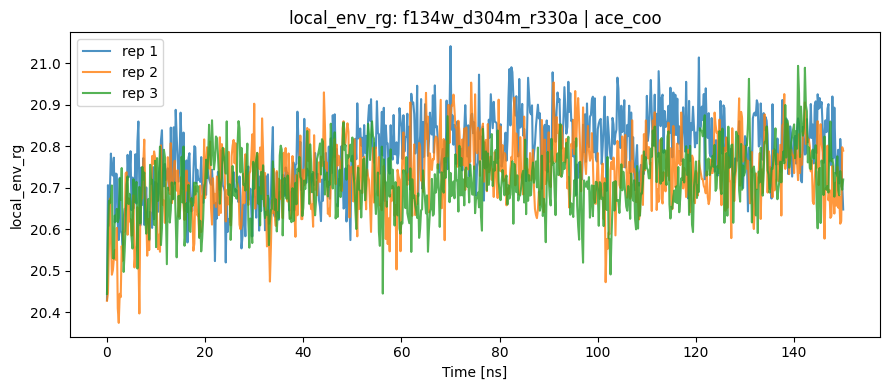

In [8]:
plot_feature_timeseries(data, "local_env_rg")

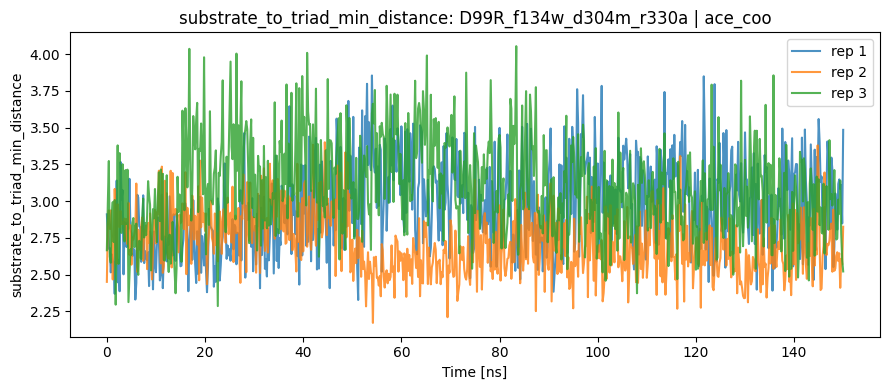

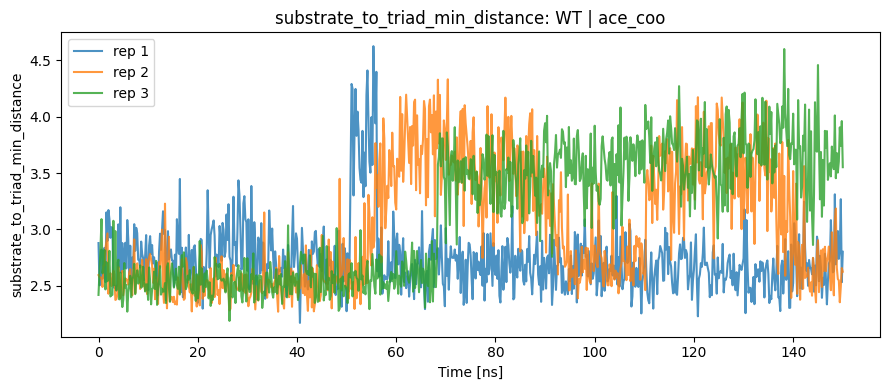

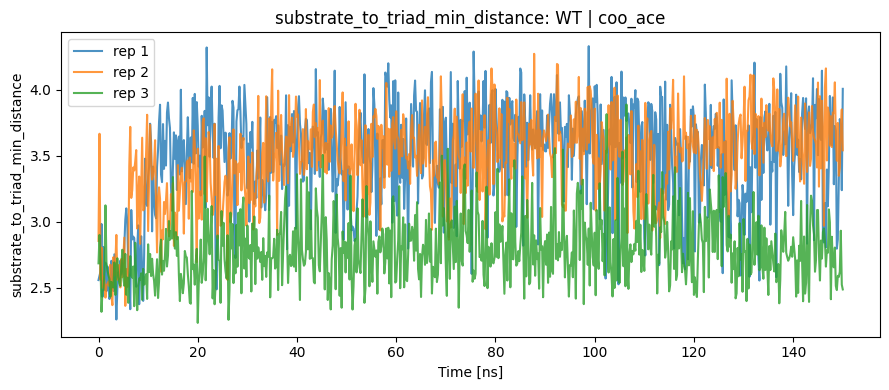

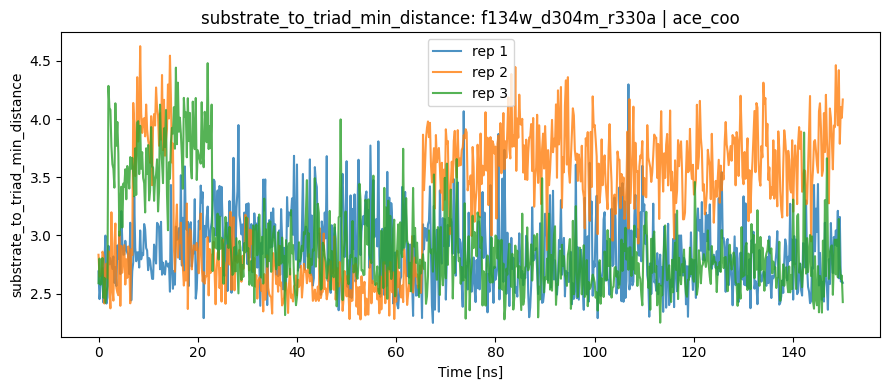

In [9]:
bound = data[data["state"] == "bound"].copy()

plot_feature_timeseries(bound, "substrate_to_triad_min_distance")

In [10]:
def boxplot_feature(df, feature):
    labels = []
    values = []

    for (variant, condition), sub in df.groupby(["variant", "condition"]):
        labels.append(f"{variant}\n{condition}")
        values.append(sub[feature].dropna().values)

    plt.figure(figsize=(12, 5))
    plt.boxplot(values, labels=labels, showfliers=False)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(feature)
    plt.title(feature)
    plt.tight_layout()
    plt.show()

/tmp/dwp46550/login23-1_227351/ipykernel_288362/3899158641.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showfliers=False)


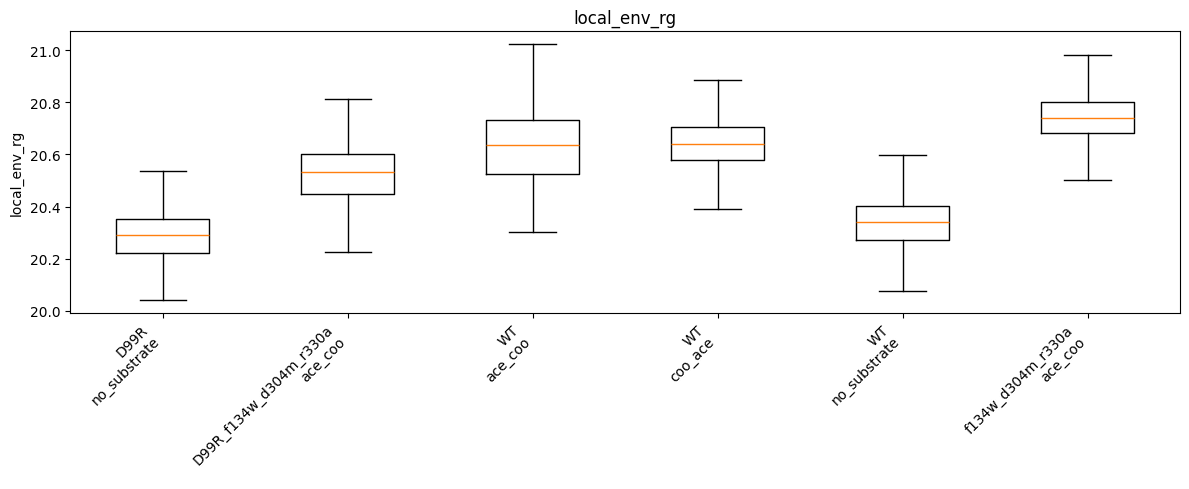

In [11]:
boxplot_feature(data, "local_env_rg")

/tmp/dwp46550/login23-1_227351/ipykernel_288362/3899158641.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showfliers=False)


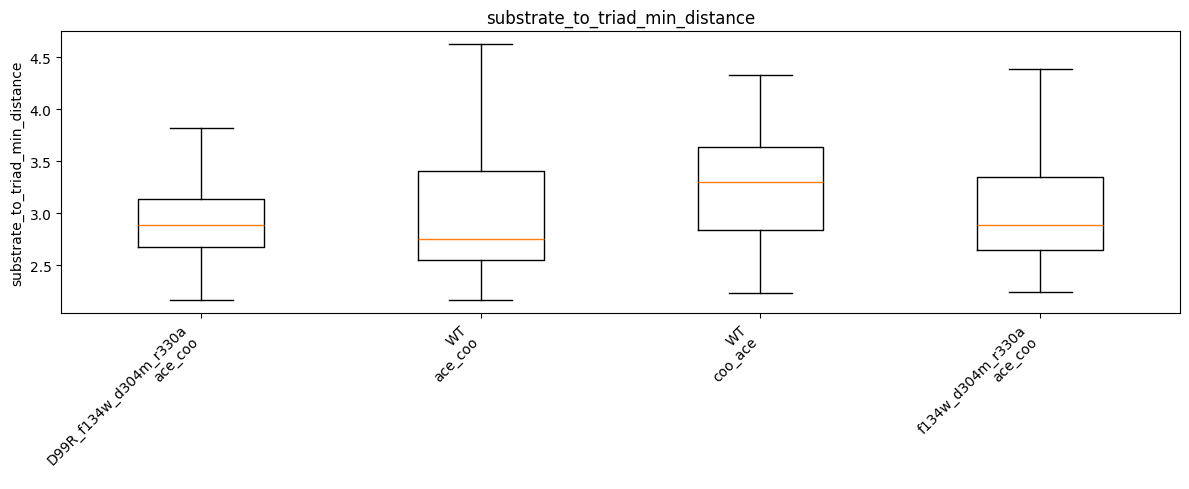

In [12]:
boxplot_feature(bound, "substrate_to_triad_min_distance")

In [13]:
replicate_means = (
    data
    .groupby(["variant", "condition", "replicate"])[feature_cols]
    .mean()
    .reset_index()
)

replicate_means.head()

,variant,condition,replicate,protein_rg,local_env_rg,local_env_n_atoms,local_env_to_triad_min_distance,backbone_rmsd,triad_d01,triad_d02,triad_d12,triad_area,substrate_rg,substrate_to_triad_min_distance,substrate_to_local_env_contacts_4A,substrate_to_local_env_contacts_5A
0,D99R,no_substrate,1,30.831994,20.342644,2203.0,1.882869,1.643844,4.283407,5.369870,4.795695,9.550626,NaN,NaN,NaN,NaN
1,D99R,no_substrate,2,30.802271,20.214978,2173.0,1.900582,1.472008,4.321321,5.595602,4.929378,10.009265,NaN,NaN,NaN,NaN
2,D99R,no_substrate,3,30.839516,20.306206,2125.0,1.917083,1.483455,4.639441,5.928990,6.765156,12.694985,NaN,NaN,NaN,NaN
3,D99R_f134w_d304m_r330a,ace_coo,1,30.859069,20.423470,2271.0,1.864111,1.775350,3.448962,5.477276,5.654313,9.055850,7.357675,2.966222,194.59787,577.033289
4,D99R_f134w_d304m_r330a,ace_coo,2,31.032005,20.585771,2274.0,1.955393,2.038167,4.500016,5.662172,4.717551,10.205073,6.199434,2.715420,315.79494,948.584554


In [14]:
feature = "substrate_to_triad_min_distance"

pivot = (
    bound
    .groupby(["variant", "condition", "replicate"])[feature]
    .mean()
    .reset_index()
    .pivot_table(index=["variant", "condition"], columns="replicate", values=feature)
)

pivot

replicate                                1         2         3
variant                condition                              
D99R_f134w_d304m_r330a ace_coo    2.966222  2.715420  3.092527
WT                     ace_coo    2.738189  3.017385  3.125692
                       coo_ace    3.482811  3.477548  2.792025
f134w_d304m_r330a      ace_coo    2.862458  3.290429  2.917099

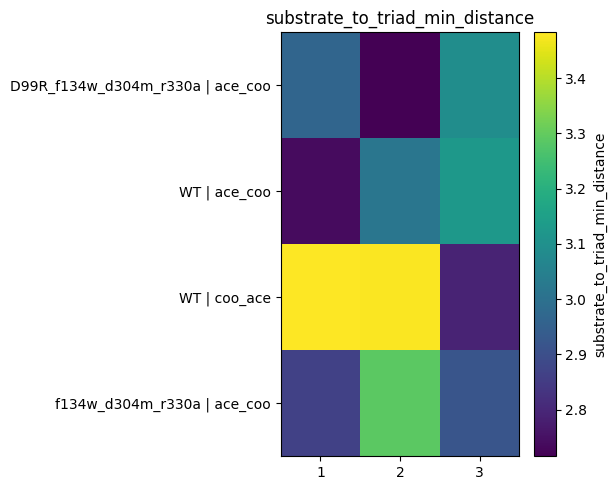

In [15]:
plt.figure(figsize=(6, 5))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label=feature)
plt.yticks(range(len(pivot.index)), [f"{i[0]} | {i[1]}" for i in pivot.index])
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.title(feature)
plt.tight_layout()
plt.show()

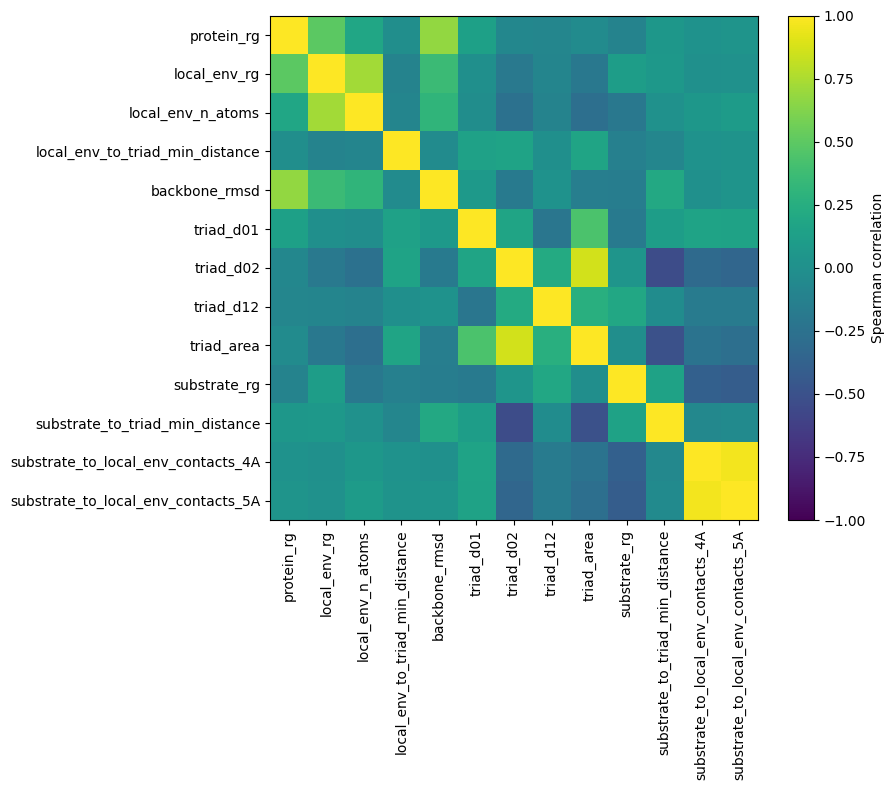

In [16]:
corr = data[feature_cols].corr(method="spearman")

plt.figure(figsize=(9, 8))
plt.imshow(corr.values, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Spearman correlation")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features = [
    c for c in feature_cols
    if data[c].notna().mean() > 0.8
]

X = replicate_means[pca_features].copy()
X = X.fillna(X.mean())

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

pca_df = replicate_means[["variant", "condition", "replicate"]].copy()
pca_df["PC1"] = pcs[:, 0]
pca_df["PC2"] = pcs[:, 1]

print("Explained variance:", pca.explained_variance_ratio_)
pca_df.head()

Explained variance: [0.40223046 0.21514979]


,variant,condition,replicate,PC1,PC2
0,D99R,no_substrate,1,1.111901,-0.817686
1,D99R,no_substrate,2,2.570556,-0.910649
2,D99R,no_substrate,3,4.700823,0.496475
3,D99R_f134w_d304m_r330a,ace_coo,1,0.527541,-2.161380
4,D99R_f134w_d304m_r330a,ace_coo,2,-0.957662,3.362461


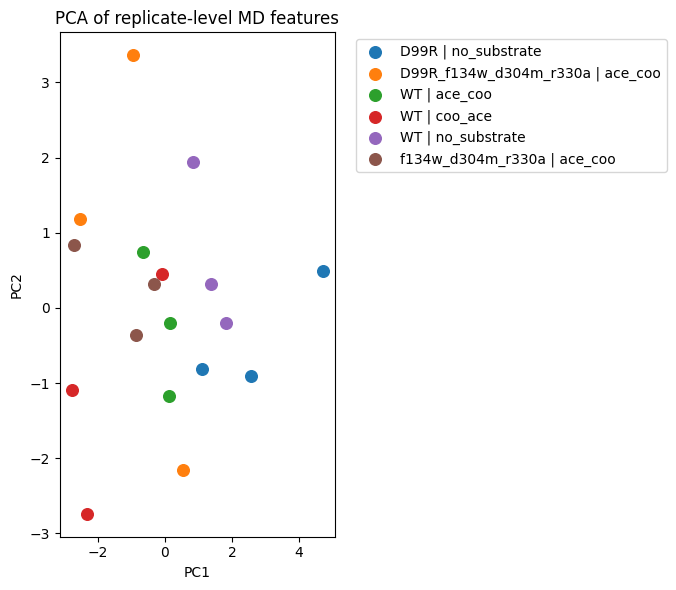

In [18]:
plt.figure(figsize=(7, 6))

for (variant, condition), sub in pca_df.groupby(["variant", "condition"]):
    plt.scatter(sub["PC1"], sub["PC2"], label=f"{variant} | {condition}", s=70)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of replicate-level MD features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=["PC1_loading", "PC2_loading"]
)

loadings.sort_values("PC1_loading", key=abs, ascending=False).head(10)

,PC1_loading,PC2_loading
triad_area,0.417498,0.308418
local_env_rg,-0.397154,0.038376
backbone_rmsd,-0.377375,0.313871
local_env_n_atoms,-0.367604,-0.070092
triad_d02,0.366038,0.231168
triad_d12,0.336301,-0.124004
protein_rg,-0.308468,0.508913
local_env_to_triad_min_distance,0.216976,0.501659
triad_d01,-0.033264,0.469583
